In [2]:
import scanpy as sc
import sys
sys.path.append('/Users/amossi/Documents/code/')
import FISHspace as sp
from scipy.spatial import KDTree
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%load_ext autoreload
%autoreload 2

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [15]:
palette = {
    'AC-like':'#2ecc71',#inchworm B4FF9F
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    
    
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F
    'AC-like 8':'#2ecc71',#inchworm B4FF9F

    'preOPC-like 1':'#7befb2',#'#c2f970'

    'WR Periphery1': '#EDE8F3',
    'WR Periphery2': '#E2D8EA',
    'WR Periphery3': '#D6BEDD',
    'WR Endo.Ass.': '#CFA8D1',
    'WR nIPC': '#CA90C5',
    'WR OPC': '#D873B6',
    'WR HYPR1': '#C50F53',
    'WR HYPR2': '#840034',
        
    'nIPC-like':'#FFF192',
    'nIPC-like 1':'#FFF192',
    'nIPC-like 2':'#FFF192',
    'nIPC-like 3':'#FFF192',

    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    
    'OPC-like 1':'#89c4f4', #bright turquoise
    'OPC-like 2':'#89c4f4', #bright turquoise
    'OPC-like 3':'#89c4f4', #bright turquoise
    'OPC-like':'#89c4f4',
    
    #'Endothelial':'#d5b8ff', #mauve
    'Endothelial 1':'#8c14fc',#'#d5b8ff', #mauve
    'Endothelial':'#8c14fc',#'#d5b8ff', #mauve
    'Mural cell': '#8c14fc',  #electric indigo
    'Mural cell 1': '#8c14fc',  #electric indigo
    'Mural': '#8c14fc',  #electric indigo
    
    'Fibroblast': '#fbe7ef',
    'FB-like 2': '#FF6EC7', #fff9de
    'FB-like 3': '#FF6EC7', #fff9de
     #'FB-like 1': '#FF6EC7', #fff9de

    'Mono 1': '#c8f7c5',#'#e6d9cb',#'#cdd1e4',#'#f4ede4',
    'Mono 2': '#FBFCFA',
    
    'TAM-MDM 1':'#e88474',#'#F5C9B0',
    'TAM-MDM 2':'#A94A54',
    
    'TAM-MDM 3':'#89c4f4',#'#95a5a6',#'#ecd9dd',
    'TAM-MDM 4':'#DC9D57',#'#A5765C',
    
    'TAM-BDM 1':'#e88474',#'#F5C9B0',
    'TAM-BDM 2':'#A94A54',
    
    'TAM-BDM 3':'#89c4f4',#'#95a5a6',#'#ecd9dd',
    'TAM-BDM 4':'#DC9D57',#'#A5765C',
    
    'TAM-MG':'#825e5c', #'#00b5cc' (blue),
    
    'DC': '#a6915c',
}

palette_classes = {
    'GBL-like':'#c2f970',#'#c2f970'
    'AC-like':'#2ecc71',#inchworm B4FF9F
    'preOPC-like':'#7befb2',#'#c2f970'

    #'MES-like': '#EDE8F3',
    'WR': '#e76d89',
    'nIPC-like':'#FFF192',
    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    
    'OPC-like':'#89c4f4',

    'FB-like': '#f1e7fe',#'#FF6EC7', #fff9de

}

In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)

import pandas as pd
adata.obs['m-states'] = pd.Categorical(['Mural' if x.count('Mural') else x for x in adata.obs['m-states']])
adata.obs['Class'] = pd.Categorical(['unknown' if x.count('FB-like 1') else x for x in adata.obs['m-states']])
adata.obs['Class'] = pd.Categorical([x.split(' ')[0] for x in adata.obs.Class])

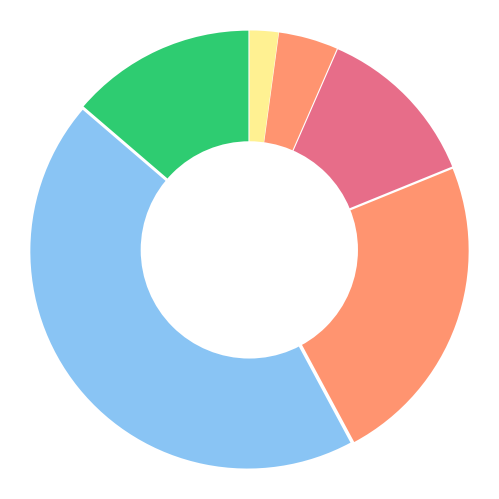

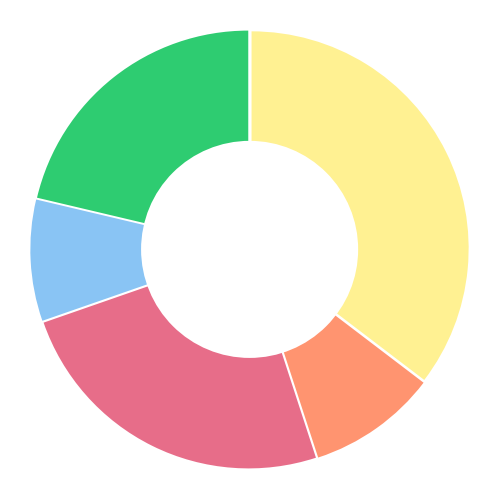

In [5]:
import matplotlib.pyplot as plt
# Pie chart
for s in ['SL023','SL034']:
    sadata = adata[adata.obs.Sample == s]
    sadata = sadata[sadata.X.sum(axis=1)>20]
    
    #df_table = sadata.obs.pivot_table(values='Area', index='Class', aggfunc=np.sum)
    #df_table = df_table.loc[list(palette_classes.keys()),:]
    #p = df_table.Area/df_table.Area.sum() *100
    #df_table = df_table[p > 2.5]
    #classes = df_table.index.values
    #counts = df_table.Area.values
    
    classes, counts = np.unique(sadata.obs['Class'], return_counts=True)
    
    counts = counts[np.isin(classes,  list(palette_classes.keys()))]
    classes = classes[np.isin(classes, list(palette_classes.keys()))]
    
    p = counts/counts.sum() *100 > 1.5
    counts = counts[p]
    classes = classes[p]
    
    

    labels = [c.split('-')[0] for c in classes]
    sizes = counts
    #colors
    colors = [palette_classes[x] for x in classes]
    #explsion
    explode = [0.01 for c in classes]
    fig1, ax1 = plt.subplots(1,1,figsize=(5,5))
    kwargs={'fontsize':16},
    ax1.pie(
        sizes, 
        colors = colors, 
        #labels=labels, 
        #autopct='%1.1f%%', 
        startangle=90, 
        pctdistance=0.85,
        labeldistance=0.75,
        explode = explode,
        textprops={'fontsize': 12}
        #kwargs=**kwargs,
    )
    #draw circle
    centre_circle = plt.Circle((0,0),0.50,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    # Equal aspect ratio ensures that pie is drawn as a circle
    ax1.axis('equal')  
    plt.tight_layout()
    plt.savefig(f'figures/pie{s}.pdf')
    plt.show()

INFO:root:First filter, 40930 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 19288 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


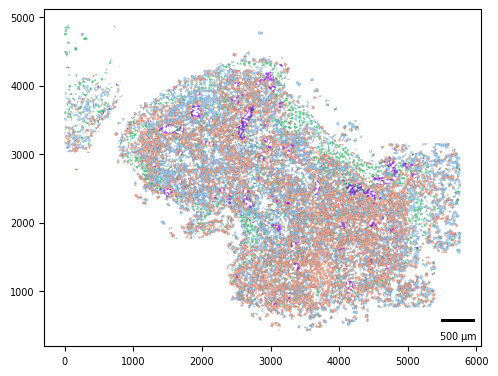

In [7]:

sp.pl.plot_polygons(
    adata,
    sample='SL023',
    palette=palette,
    #geometry_key='Centroid',
    cluster_key= 'Class',
    clusters = ['AC-like','OPC-like','RG-like','Mural','Endothelial'],
    markersize=.25,
    figsize=(5,5),
    xlim=(3000, 9000),
    ylim=(0,6000),

    show_scalebar=True,
    show_axis=True,
    #save=True,
    #savepath='figures/SL023.svg',
    
)

INFO:root:First filter, 70126 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2843 cells left
INFO:root:Expression range: 1.0 - 6.75
INFO:root:First filter, 2623 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 116 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


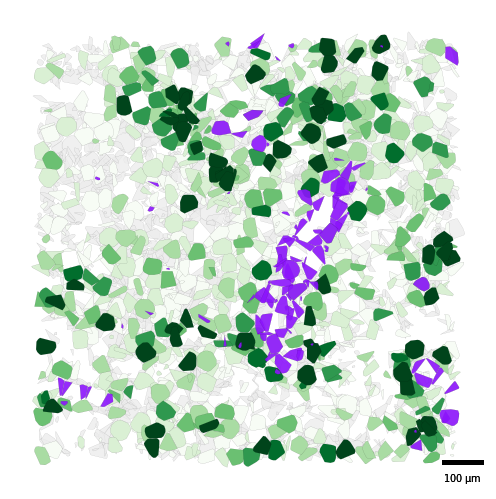

In [9]:
xlim=(5000, 6000)
ylim=(3000,4000)

fig,ax = plt.subplots(1,1 ,figsize=(5,5))
sp.pl.plot_polygons_expression(
    adata,#[adata.obs.Class == 'AC-like'],
    sample='SL023',
    genes=['CRYAB'],
    cmap='Greens',
    cluster_key='m-states',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    mquant=0.99,
    ax = ax

)

sp.pl.plot_polygons(
    adata,
    sample='SL023',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=0.9,
    show_axis=True,
    palette= {'Endothelial':'#8c14fc',  'Mural': '#8c14fc'},
    ax=ax,
)

plt.savefig('figures/CRYAB_SL023.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')

INFO:root:First filter, 70126 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 30518 cells left
INFO:root:Expression range: 1.0 - 5.0


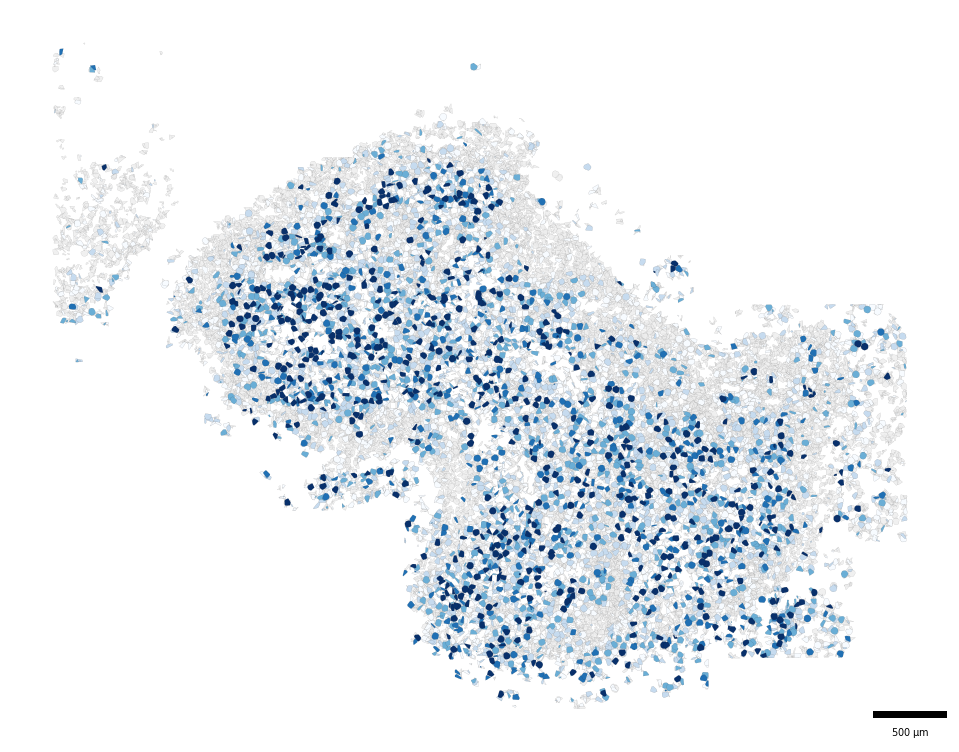

In [10]:
xlim=(3000, 9000)
ylim=(0,6000)

sp.pl.plot_polygons_expression(
    adata,#[adata.obs.Class == 'AC-like'],
    sample='SL023',
    genes=['CDK4'],
    cmap='Blues',
    cluster_key='m-states',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    mquant=0.99,
    save=True,
    savepath='figures/SL023_CDK4.svg',
)

# MDM2 - NPC

INFO:root:First filter, 40484 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 20021 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


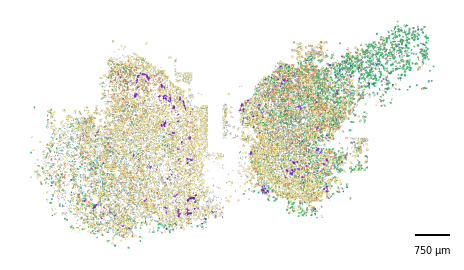

In [18]:
sp.pl.plot_polygons(
    adata,
    sample='SL034',
    palette=palette,
    #geometry_key='Centroid',
    cluster_key= 'Class',
    clusters = ['AC-like','OPC-like','RG-like','nIPC-like','nIPC-RG-like','Mural','Endothelial'],
    alpha=1.0,
    figsize=(5,5),
    xlim=(9000, 17500),
    ylim=(0,5000),

    show_scalebar=True,
    show_axis=False,
    save=True,
    savepath='figures/SL034.svg',
    
)

INFO:root:First filter, 40484 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 20021 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


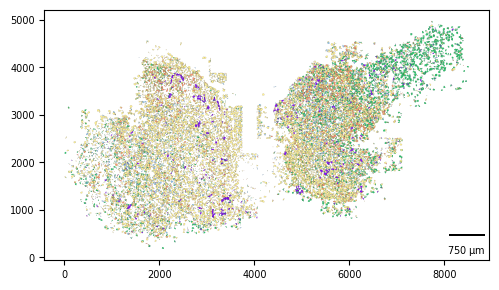

In [19]:
sp.pl.plot_polygons(
    adata,
    sample='SL034',
    palette=palette,
    #geometry_key='Centroid',
    cluster_key= 'Class',
    clusters = ['AC-like','OPC-like','RG-like','nIPC-like','nIPC-RG-like','Mural','Endothelial'],
    alpha=1.0,
    figsize=(5,5),
    xlim=(9000, 17500),
    ylim=(0,5000),

    show_scalebar=True,
    show_axis=True, 
    
)

INFO:root:First filter, 110402 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 3449 cells left
INFO:root:Expression range: 2.0 - 13.0
INFO:root:First filter, 1773 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 79 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


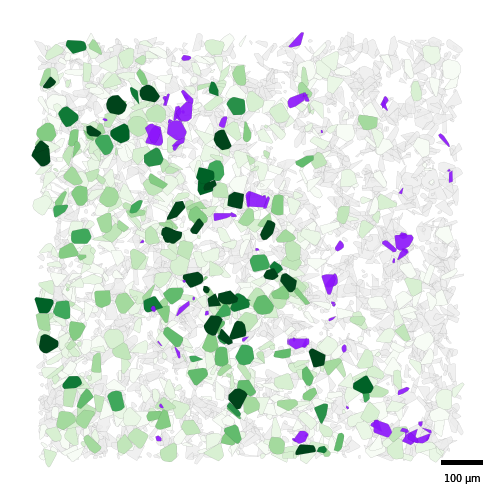

In [21]:
xlim=(11500, 12500)
ylim=(2000,3000)

fig,ax = plt.subplots(1,1 ,figsize=(5,5))
sp.pl.plot_polygons_expression(
    adata,#[adata.obs.Class == 'AC-like'],
    sample='SL034',
    genes=['CRYAB'],
    cmap='Greens',
    cluster_key='m-states',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    mquant=0.99,
    ax = ax,
    bgval=1,
)

sp.pl.plot_polygons(
    adata,
    sample='SL034',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=0.9,
    show_axis=True,
    palette= {'Endothelial':'#8c14fc',  'Mural': '#8c14fc',},
    ax=ax,
)

plt.savefig('figures/CRYAB_SL034.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')

In [ ]:
xlim=(9000, 17500)
ylim=(0,5000)


sp.pl.plot_polygons_expression(
    adata,#[adata.obs.Class == 'AC-like'],
    sample='SL034',
    genes=['MDM2'],
    cmap='Blues',
    cluster_key='m-states',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    #figsize=(5,5),
    figsize=(5,5),
    mquant=0.99,
    save=True,
    savepath='figures/SL034_MDM2.svg',
)

INFO:root:First filter, 110402 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 57774 cells left
INFO:root:Expression range: 1.0 - 16.0
